# **GreenTravel Intelligence Challenge**

**The objective of this challenge is to develop a binary classification model that predicts whether a business trip belongs to the HighCarbon[1] class based on the information avail-
able before the trip is undertaken.**

EDA has been performed along with multiple feature engineering techniques.


1.   Duplicates and missing values checked.
2.   Columns that unique identifiers were removed.
3.   Leakage columns containing CO2e emissions data were dropped.
4.   More features removed based on feature importance.

**It has been observed that our selected features have high predictive power. Even after adding few engineered features the results didn't improve.**

So this simplistic model has been used as it produced good validation accuracy, f1 and roc scores.

Train Accuracy            : 0.9933

Validation Accuracy       : 0.9936

F1 Score (Validation)     : 0.9873

Confusion Matrix:

 [[9760   33]

 [  50 3215]]

**Final ROC score: 0.9995**




In [2]:
!pip install catboost

In [3]:
#import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    classification_report,
    recall_score,
    f1_score,
    confusion_matrix
)

In [4]:
#import datasets
train = pd.read_csv("public_trip_data.csv")
test = pd.read_csv("private_trip_data.csv")

In [5]:
#checking duplicates
print(train.duplicated().sum())
print(test.duplicated().sum())

0
0


In [6]:
# checking missing values
print(train.isna().sum())


TripID                      0
DepartureLocationCountry    0
DepartureLocationCity       0
ArrivalLocationCountry      0
ArrivalLocationCity         0
ShippingType                0
ShippingTypeDescription     0
Purpose                     0
OutOfPolicy                 0
EntitiyCode                 0
EmployeeNumber              0
BusinessUnit                0
HotelNights                 0
NetCosts                    0
Departure_CO2e              0
Return_CO2e                 0
Hotel_CO2e                  0
Spend_CO2e                  0
TotalCO2e                   0
HighCarbon                  0
dtype: int64


In [7]:
#creating copies
train_fe = train.copy()
test_fe = test.copy()

In [8]:
#dropping columns that are unique identifiers
#EmployeeNumber is originally not in private dataset
train_fe.drop(columns=["EmployeeNumber", "TripID"], inplace=True)
test_fe.drop(columns=["TripID"], inplace=True)

In [9]:
#dropping leakage columns from training set
leakage_cols = [
    "Departure_CO2e",
    "Return_CO2e",
    "Hotel_CO2e",
    "Spend_CO2e",
    "TotalCO2e"

]

train_fe.drop(columns=leakage_cols, inplace=True)

In [10]:
#dropping columns that are collinear
#ShippingType and ShippingTypeDescription explain the same thing.
train_fe.drop(columns=["ShippingType"], inplace=True)
test_fe.drop(columns=["ShippingType"], inplace=True)

In [11]:
#dropped more columns based on feature importance on the first model run
# ==================================================
# Feature Importance (First Run)
# ==================================================
#                      Feature  Importance
# 4    ShippingTypeDescription   34.186573
# 3        ArrivalLocationCity   28.773800
# 0   DepartureLocationCountry   15.049296
# 9                HotelNights   14.639008
# 1      DepartureLocationCity    4.183318
# 2     ArrivalLocationCountry    2.783614
# 6                OutOfPolicy    0.377645
# 8               BusinessUnit    0.006546
# 5                    Purpose    0.000200
# 7                EntitiyCode    0.000000
# 10                  NetCosts    0.000000

train_fe.drop(columns=["Purpose", "NetCosts", "BusinessUnit", "EntitiyCode"], inplace=True)
test_fe.drop(columns=["Purpose", "NetCosts", "BusinessUnit", "EntitiyCode"], inplace=True)


In [12]:
print(train_fe.shape)
print(test_fe.shape)

(65289, 8)
(21764, 7)


In [13]:
X = train_fe.drop(columns=["HighCarbon"])

y = train_fe["HighCarbon"]

X_test = test_fe.copy()

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
# printing categorical features
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(cat_features)

['DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingTypeDescription', 'OutOfPolicy']


In [16]:
#train pool
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)

In [17]:
#model training
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    auto_class_weights="Balanced",
    verbose=100  # Prints progress log every 100 iterations
)



model.fit(train_pool, eval_set=val_pool)

0:	test: 0.9845094	best: 0.9845094 (0)	total: 119ms	remaining: 59.5s
100:	test: 0.9994450	best: 0.9994450 (86)	total: 5.29s	remaining: 20.9s
200:	test: 0.9994519	best: 0.9994519 (167)	total: 10.3s	remaining: 15.3s
300:	test: 0.9993910	best: 0.9994519 (167)	total: 14.2s	remaining: 9.38s
400:	test: 0.9993910	best: 0.9994519 (167)	total: 19.8s	remaining: 4.88s
499:	test: 0.9993910	best: 0.9994519 (167)	total: 23.5s	remaining: 0us

bestTest = 0.9994519478
bestIteration = 167

Shrink model to first 168 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [18]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("="*50)
print("Feature Importance")
print("="*50)

print(feature_importance)

Feature Importance
                    Feature  Importance
4   ShippingTypeDescription   36.817527
3       ArrivalLocationCity   27.434767
0  DepartureLocationCountry   16.209246
6               HotelNights    9.793993
2    ArrivalLocationCountry    6.375194
1     DepartureLocationCity    3.192705
5               OutOfPolicy    0.176569


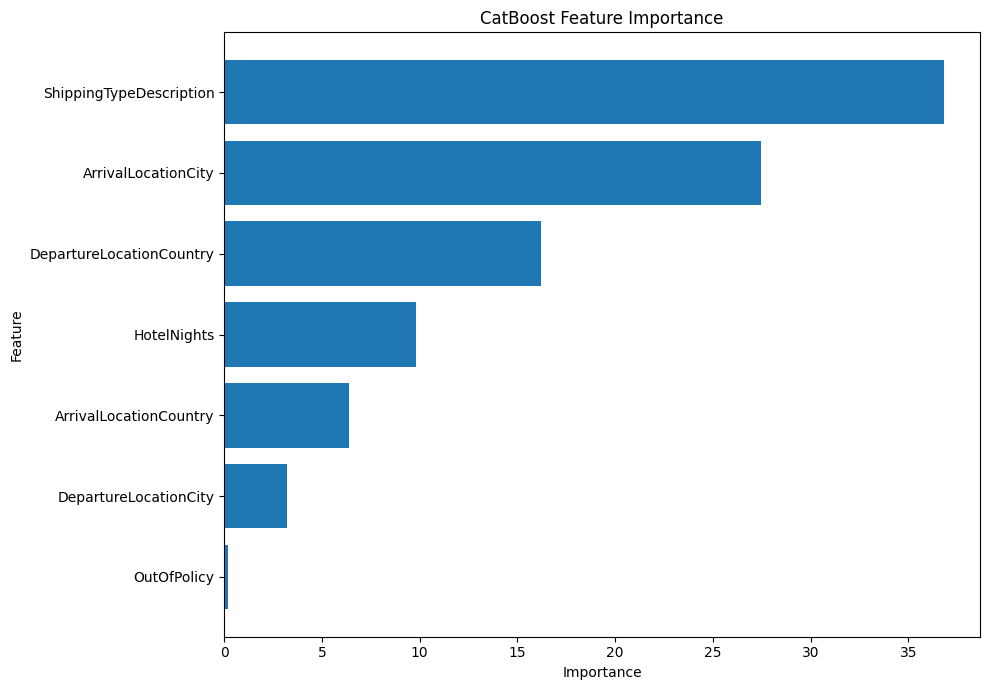

In [19]:
# Feature Importance Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("CatBoost Feature Importance")

plt.tight_layout()

plt.show()

In [20]:
# ==========================================
# Model Evaluation & Metrics
# ==========================================

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Probability predictions for AUC-ROC
y_train_prob = model.predict_proba(X_train)[:, 1]
y_val_prob = model.predict_proba(X_val)[:, 1]

In [21]:
# Compute all required metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
auc_roc = roc_auc_score(y_val, y_val_prob)
class_report = classification_report(y_val, y_val_pred)
conf_matrix = confusion_matrix(y_val, y_val_pred)


# Displaying Metrics
print("\n" + "=" * 50)
print(f"Train Accuracy            : {train_acc:.4f}")
print(f"Validation Accuracy       : {val_acc:.4f}")
print(f"F1 Score (Validation)     : {f1:.4f}")
print("=" * 50)
print(f"AUC-ROC Score (Validation): {auc_roc:.4f}")
print("=" * 50)
print("Confusion Matrix:\n", conf_matrix)
print("=" * 50)
print("Classification Report:\n", class_report)
print("=" * 50)


Train Accuracy            : 0.9933
Validation Accuracy       : 0.9936
F1 Score (Validation)     : 0.9873
AUC-ROC Score (Validation): 0.9995
Confusion Matrix:
 [[9760   33]
 [  50 3215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      9793
           1       0.99      0.98      0.99      3265

    accuracy                           0.99     13058
   macro avg       0.99      0.99      0.99     13058
weighted avg       0.99      0.99      0.99     13058



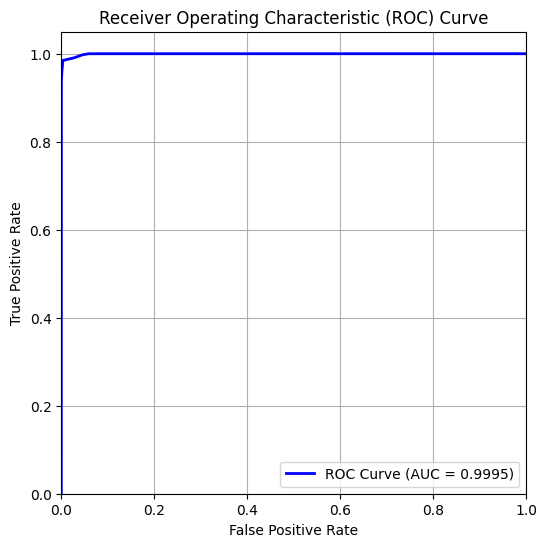

In [22]:
# Plot ROC Curve
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [23]:
#Predict on Private set with probabilities
sample_sub = pd.read_csv("sample_submission.csv")

private_pool = Pool(X_test, cat_features=cat_features)

private_preds_prob = model.predict_proba(private_pool)[:, 1]

submission = sample_sub.copy()

target_col = "HighCarbon"
submission[target_col] = private_preds_prob
# submission[target_col] = model.predict(private_pool)

submission.to_csv("final_submission.csv", index=False)

print("=" * 50)
print(submission.head(50))

    TripID  HighCarbon
0        2    0.999712
1        4    0.001276
2        5    0.948861
3       14    0.000201
4       15    0.000118
5       17    0.000032
6       22    0.999622
7       23    0.999268
8       25    0.000059
9       30    0.001809
10      35    0.996700
11      39    0.001380
12      45    0.999957
13      50    0.003088
14      51    0.000905
15      55    0.999622
16      64    0.999873
17      65    0.000953
18      68    0.004993
19      72    0.000046
20      73    0.000830
21      78    0.999798
22      80    0.000050
23      86    0.000045
24      87    0.000132
25      96    0.000053
26      97    0.000069
27     101    0.000044
28     102    0.001430
29     106    0.999911
30     107    0.000046
31     118    0.001961
32     122    0.000350
33     130    0.000968
34     140    0.999872
35     141    0.000060
36     144    0.999929
37     147    0.000142
38     157    0.999866
39     160    0.000830
40     161    0.001709
41     167    0.999983
42     168 